<div align="center">

# Blind Challenge 
### (Corso di Astrofisica computazionale Laurea magistrale)

</div>

---

# Introduzione
In questo secondo programma, denominato **Blind Challenge**, il workflow viene generalizzato per selezionare in modo completamente automatico la cosmologia più adatta a un dataset di osservazioni fornito in input. Il processo prevede:

1. **Caricamento dei dati**  
   Lettura da file delle misure (redshift, distanze, errori, …) senza alcuna informazione a priori sul modello “corretto”.  
2. **Definizione dei modelli**  
   Utilizzo di un dizionario centralizzato con tutte le configurazioni teoriche (LCDM, wCDM, w0waCDM, …), ciascuna con prior, likelihood e posterior dedicati.  
3. **Campionamento MCMC con `emcee`**  
   Per ogni modello si esegue un ensemble sampler con un numero di walker e passaggi calibrati, generando catene posteriori sfruttando la funzione `ln_posterior_new`.  
4. **Estrazione delle stime**  
   Calcolo di mediana dei parametri, percentile bands e curve teoriche normalizzate.  


L’approccio blind garantisce un’analisi **oggettiva** e **riproducibile**, dove nessun modello gode di privilegio a priori: è la risposta dei dati stessi a decretare la teoria più probabile.  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM, wCDM, w0waCDM
from scipy.constants import c
import emcee, corner 
import sys
sys.path.append("../")    

In [3]:
from pyACC.cosmology.distances import Distances

In [4]:
C_KMS = c / 1000.0  
fid_cosmo = LambdaCDM(H0=67.14, Om0=0.3169, Ode0=1-0.3169)
r_d_fid   = 147.05 

In [5]:
df = pd.read_csv("bao_data.csv")
mask = df["alpha_iso"].notna() & df["alpha_iso_err"].notna()
df = df.loc[mask].reset_index(drop=True)

z_data      = df["z"].to_numpy()
alpha_data  = df["alpha_iso"].to_numpy()
alpha_sigma = df["alpha_iso_err"].to_numpy()

print(f"→ Caricati {len(z_data)} punti da 'bao_data.csv'")
print("Prime 5:")
for i in range(min(5, len(z_data))):
    print(f" z={z_data[i]:.3f}, α_obs={alpha_data[i]:.4f} ± {alpha_sigma[i]:.4f}")

C_KMS     = 299792.458
r_d_model = 147.05  

→ Caricati 9 punti da 'bao_data.csv'
Prime 5:
 z=0.240, α_obs=0.9900 ± 0.0105
 z=0.450, α_obs=0.9885 ± 0.0092
 z=0.650, α_obs=0.9800 ± 0.0078
 z=0.850, α_obs=0.9920 ± 0.0063
 z=1.100, α_obs=0.9895 ± 0.0075


## Esempio 1: con il modello LambdaCDM

In [6]:
def dv_model(z, cosmo):
    Dc = cosmo.comoving_distance(z).value
    H  = cosmo.H(z).value
    return ((C_KMS * z * Dc**2) / H)**(1/3)

def dv_rd_model(z, cosmo):
    return dv_model(z, cosmo) / r_d_model

def build_cosmo(theta):
    H0, Om0 = theta
    return LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0)

fid_theta = (67.4, 0.315)
fid_cosmo = build_cosmo(fid_theta)

def alpha_model(theta, z):
    """α_iso(z; theta) = [D_V/r_d(theta)]/[D_V/r_d(fid)]"""
    cosmo = build_cosmo(theta)
    num   = dv_rd_model(z, cosmo)
    den   = dv_rd_model(z, fid_cosmo)
    return num/den

def ln_prior(theta):
    H0, Om0 = theta
    if 40 < H0 < 100 and 0.05 < Om0 < 0.6:
        return 0.0
    return -np.inf

def ln_likelihood(theta):
    model = alpha_model(theta, z_data)
    return -0.5 * np.sum(((alpha_data - model)/alpha_sigma)**2)

def ln_posterior(theta):
    lp = ln_prior(theta)
    return lp + ln_likelihood(theta) if np.isfinite(lp) else -np.inf


In [7]:
ndim   = 2
nwalk  = 32
nsteps = 5000
burn   = 2000

rng = np.random.default_rng(42)
# inizializza i walker uniformemente nel box del prior
p0 = rng.uniform(low=[40, 0.05], high=[100, 0.6], size=(nwalk, ndim))

# crea il sampler con la tua funzione ln_posterior già definita
sampler = emcee.EnsembleSampler(nwalk, ndim, ln_posterior)

print(f"→ Avvio MCMC esteso: {nwalk} walker, {ndim} dim, {nsteps} step")
sampler.run_mcmc(p0, nsteps, progress=True)
print("✓ MCMC esteso completato\n")

# Preleva la catena "flat" scartando il burn-in
flat_chain = sampler.get_chain(discard=burn, flat=True)

# Calcola i parametri "best" come mediana
best_H0, best_Om0 = np.median(flat_chain, axis=0)
print(f"Parametri best-fit mediana: H0 = {best_H0:.3f}, Ωm = {best_Om0:.3f}")

# Costruisci la cosmologia migliore
cosmo_best = LambdaCDM(H0=best_H0, Om0=best_Om0, Ode0=1-best_Om0)
print("Cosmologia best-fit creata:", cosmo_best)


→ Avvio MCMC esteso: 32 walker, 2 dim, 5000 step


100%|██████████| 5000/5000 [02:23<00:00, 34.84it/s]

✓ MCMC esteso completato

Parametri best-fit mediana: H0 = 68.674, Ωm = 0.302
Cosmologia best-fit creata: LambdaCDM(H0=68.67448712176892 km / (Mpc s), Om0=0.30163081048639795, Ode0=0.698369189513602, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.0)


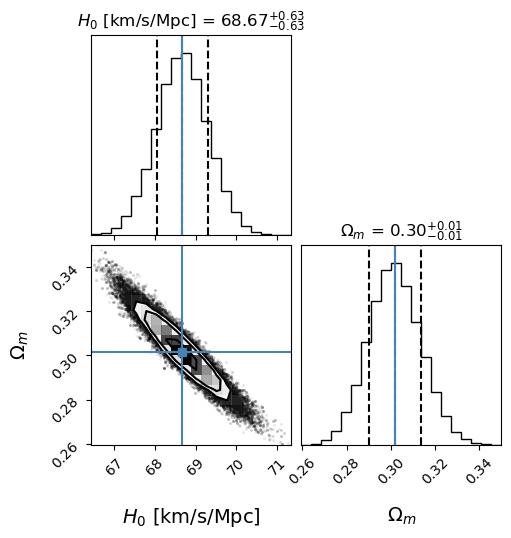

In [8]:
# Se non l'hai già installata:
# pip install corner

import matplotlib.pyplot as plt
import corner

# 1) Definisci i nomi (in LaTeX) dei tuoi parametri
labels = [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$"]

# 2) Crea il corner plot a partire dalla flat_chain
fig = corner.corner(
    flat_chain,
    labels=labels,
    show_titles=True,            # mostra la mediana in cima a ogni istogramma
    title_fmt=".2f",             # formato numerico delle title
    quantiles=[0.16, 0.5, 0.84], # calcola e riporta gli intervalli 1σ
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14},
    truths=[best_H0, best_Om0],  # linee verticali nei valori best-fit
)

# 3) Salva e/o mostra a schermo
fig.savefig("corner_plot.png", dpi=150, bbox_inches="tight")
plt.show()


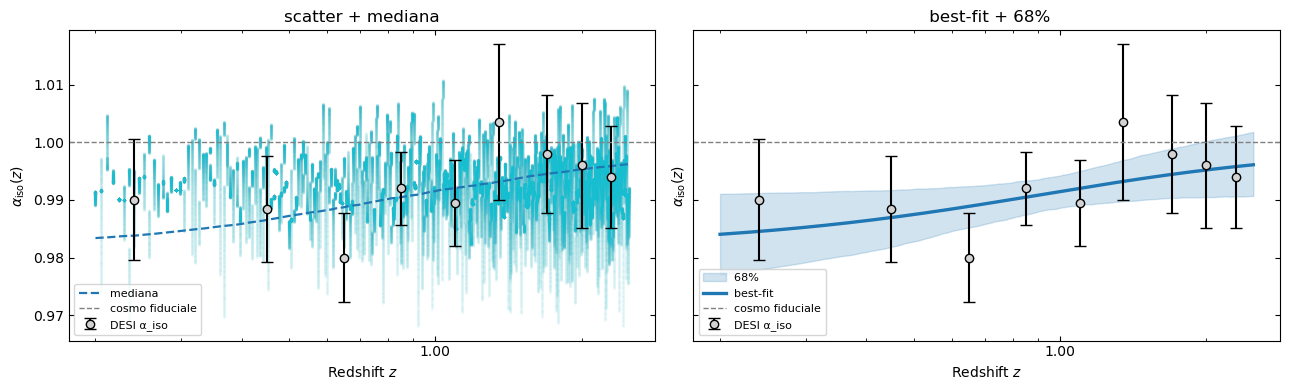

In [9]:
from matplotlib.ticker import ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt


z_dense      = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_rd_model(z_dense, fid_cosmo)   
n_band   = min(800, flat_chain.shape[0])
idx_band = rng.choice(flat_chain.shape[0], size=n_band, replace=False)

alpha_mat = np.array([
    dv_rd_model(z_dense, build_cosmo(theta)) / Dv_fid_dense
    for theta in flat_chain[idx_band]
])  

alpha_med  = np.median(alpha_mat, axis=0)
alpha_low  = np.percentile(alpha_mat, 16, axis=0)
alpha_high = np.percentile(alpha_mat, 84, axis=0)

best_H0, best_Om0 = np.median(flat_chain, axis=0)
cosmo_best       = build_cosmo((best_H0, best_Om0))
alpha_best       = dv_rd_model(z_dense, cosmo_best) / Dv_fid_dense

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
scat_idx = rng.choice(n_band, size=min(300, n_band), replace=False)
axL.scatter(
    np.repeat(z_dense, scat_idx.size),
    alpha_mat[scat_idx].ravel(),
    s=2, alpha=0.04, color="tab:cyan"
)
axL.plot(z_dense, alpha_med, ls="--", lw=1.6,
         color="tab:blue", label="mediana")

axL.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axL.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axL.set_title("scatter + mediana")

axR.fill_between(z_dense, alpha_low, alpha_high,
                 color="tab:blue", alpha=0.20, label="68% ")
axR.plot(z_dense, alpha_best, lw=2.4, color="tab:blue",
         label=fr"best-fit ")

axR.errorbar(z_data, alpha_data, yerr=alpha_sigma,
             fmt="o", ms=6, mfc="lightgray", mec="k",
             ecolor="k", capsize=4, label="DESI α_iso")
axR.axhline(1, ls="--", lw=1, color="grey", label="cosmo fiduciale")
axR.set_title(" best-fit + 68%")

for ax in (axL, axR):
    ax.set_xscale("log")
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"$\alpha_{\mathrm{iso}}(z)$")
    #ax.set_xlim(0.02, 2.5)
    #ax.set_ylim(0.9, 1.1)

    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.get_major_formatter().set_scientific(False)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.get_major_formatter().set_scientific(False)

    ax.tick_params(
        axis='both', which='both',
        direction='in', top=True, right=True,
        labeltop=False, labelright=False
    )
    ax.legend(fontsize=8, loc='lower left')

fig.tight_layout()
plt.show()


## Esempio 2: per 4 modelli cosmologici

In [10]:
C_KMS     = 299_792.458   # km/s
r_d_model = 147.05        # Mpc

def dv_modelNew(z, cosmo):
    Dc = cosmo.comoving_distance(z).value
    H  = cosmo.H(z).value
    return ((C_KMS * z * Dc**2) / H)**(1/3)

def dv_rd_modelNew(z, cosmo):
    return dv_modelNew(z, cosmo) / r_d_model

def build_cosmoNew(theta, tag="lcdm"):
    H0, Om0 = theta[0], theta[1]
    if tag == "lcdm":
        return LambdaCDM(H0=H0, Om0=Om0, Ode0=1-Om0)
    if tag == "wcdm":
        w0 = theta[2]
        return wCDM(H0=H0, Om0=Om0, Ode0=1-Om0, w0=w0)
    if tag == "w0wa":
        w0, wa = theta[2], theta[3]
        return w0waCDM(H0=H0, Om0=Om0, Ode0=1-Om0, w0=w0, wa=wa)
    if tag == "okcdm":
        Ok0 = theta[2]
        Ol0 = 1 - Om0 - Ok0
        return LambdaCDM(H0=H0, Om0=Om0, Ode0=Ol0)
    raise ValueError(f"Tag cosmologia '{tag}' non riconosciuto")

def ln_priorNew(theta, tag="lcdm"):
    H0, Om0 = theta[0], theta[1]
    if not (40 < H0 < 100 and 0.05 < Om0 < 0.6):
        return -np.inf
    if tag == "wcdm":
        w0 = theta[2]
        if not (-3.0 < w0 < 0.0):
            return -np.inf
    if tag == "w0wa":
        w0, wa = theta[2], theta[3]
        if not (-3.0 < w0 < 0.0 and -3.0 < wa < 3.0):
            return -np.inf
    if tag == "okcdm":
        Ok0 = theta[2]
        if not (-0.5 < Ok0 < 0.5):
            return -np.inf
    return 0.0

def ln_likelihoodNew(theta, tag="lcdm"):
    cosmo = build_cosmoNew(theta, tag)
    model = dv_rd_modelNew(z_data, cosmo) / dv_rd_modelNew(z_data, fid_cosmo)
    return -0.5 * np.sum(((alpha_data - model) / alpha_sigma)**2)

def ln_posteriorNew(theta, tag="lcdm"):
    lp = ln_priorNew(theta, tag)
    return lp + ln_likelihoodNew(theta, tag) if np.isfinite(lp) else -np.inf


In [ ]:
MODELS = {
    'ΛCDM':    'lcdm',
    'wCDM':    'wcdm',
    'w0waCDM': 'w0wa',
    'ΩkCDM':   'okcdm',
}

ndim   = 4   # massima dimensione dello spazio dei parametri    
nwalk  = 16  # numero di walker nell'ensemble   
nsteps = 2000  # passi di MCMC (per ciascun walker) 
burn   = 1000    # quanti passi scartare come “burn-in”
rng    = np.random.default_rng(42) # generatore di numeri casuali con seed fisso (per la riproducibilità)

samplers = {}  #conterrà l’oggetto EnsembleSampler usato per ciascun modello.
results  = {}  #conterrà il vettore dei valori mediani dei parametri (output finale).

for name, tag in MODELS.items():
    ndim_eff = 2 if tag == "lcdm" else (3 if tag in ("wcdm", "okcdm") else 4)
    low  = [40.0, 0.05]
    high = [100.0, 0.6]
    if tag == "wcdm":
        low += [-3.0]; high += [0.0]
    if tag == "w0wa":
        low += [-3.0, -3.0]; high += [0.0, 3.0]
    if tag == "okcdm":
        low += [-0.5]; high += [0.5]
    # inizializza i walker uniformemente nel box del prior
    p0 = rng.uniform(low=low, high=high, size=(nwalk, ndim_eff))
    sampler = emcee.EnsembleSampler(nwalk, ndim_eff, ln_posteriorNew, args=(tag,))
    print(f"→ {name}: {nwalk} walker, {ndim_eff} dim, {nsteps} step")
    sampler.run_mcmc(p0, nsteps, progress=True) #lancia l’MCMC per 2000 passi a partire da p0.
    samplers[name] = sampler

    flat_chain = sampler.get_chain(discard=burn, flat=True) # Scarta i primi 1000 passi (burn-in) e appiattisce la catena
    # Calcola i parametri "best" come mediana
    med = np.median(flat_chain, axis=0)
    results[name] = med
    print(f"   θ_med ({name}) = {med}")

print("✓ Tutte le catene estese concluse")

→ ΛCDM: 16 walker, 2 dim, 2000 step


100%|██████████| 2000/2000 [00:28<00:00, 70.58it/s]


   θ_med (ΛCDM) = [68.69940845  0.30126013]
→ wCDM: 16 walker, 3 dim, 2000 step


100%|██████████| 2000/2000 [00:35<00:00, 55.84it/s]


   θ_med (wCDM) = [67.92417054  0.29794189 -0.93998178]
→ w0waCDM: 16 walker, 4 dim, 2000 step


100%|██████████| 2000/2000 [00:30<00:00, 64.64it/s]


   θ_med (w0waCDM) = [67.35629594  0.32029417 -0.81535203 -0.64795566]
→ ΩkCDM: 16 walker, 3 dim, 2000 step


100%|██████████| 2000/2000 [00:29<00:00, 67.66it/s]

   θ_med (ΩkCDM) = [6.81690644e+01 2.86049083e-01 5.97572874e-02]
✓ Tutte le catene estese concluse


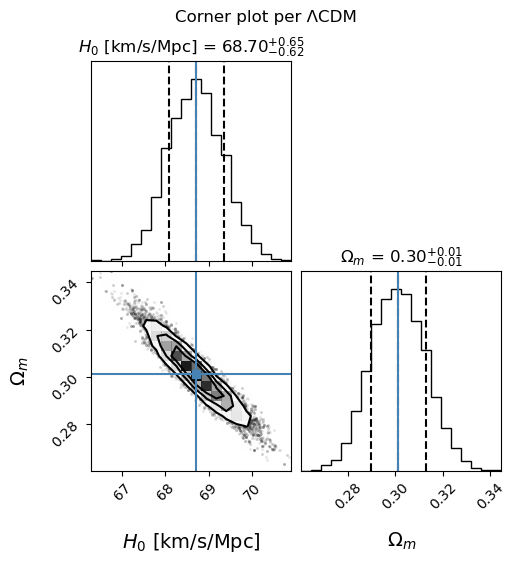

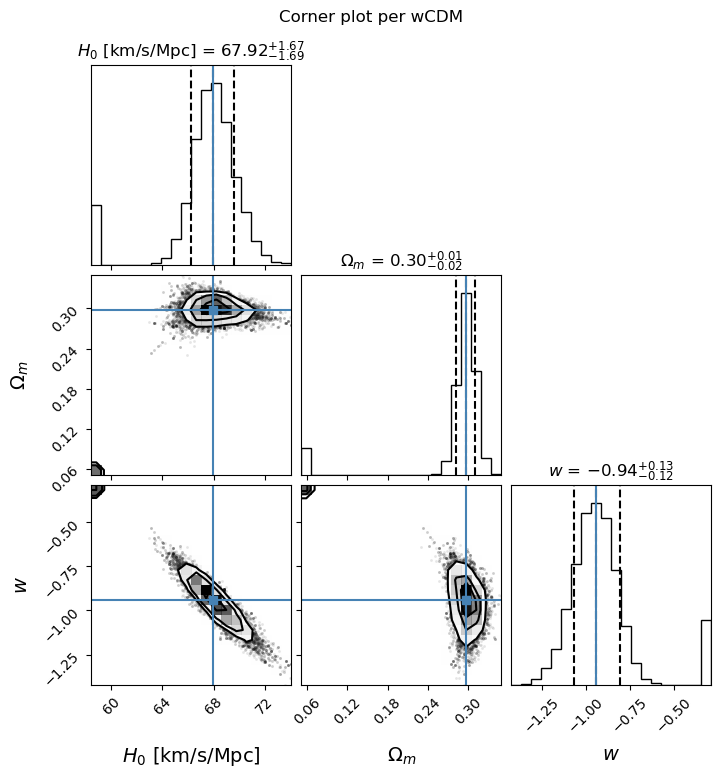

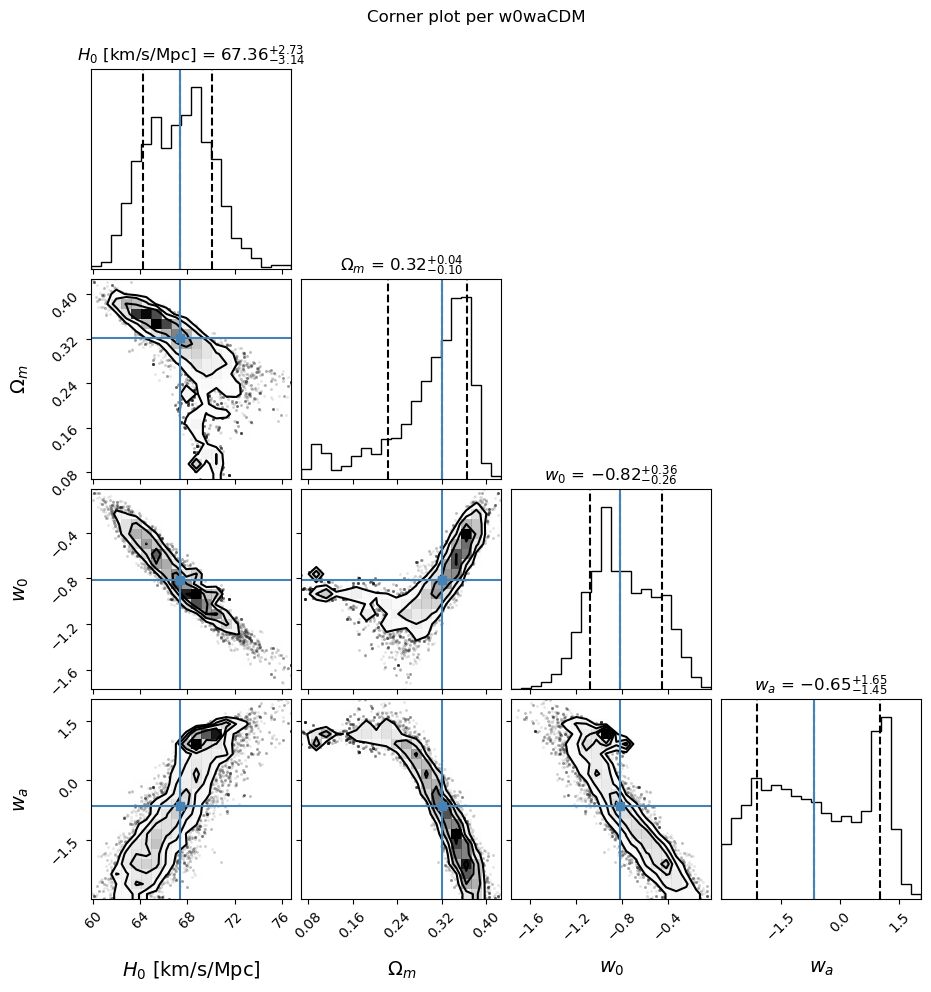

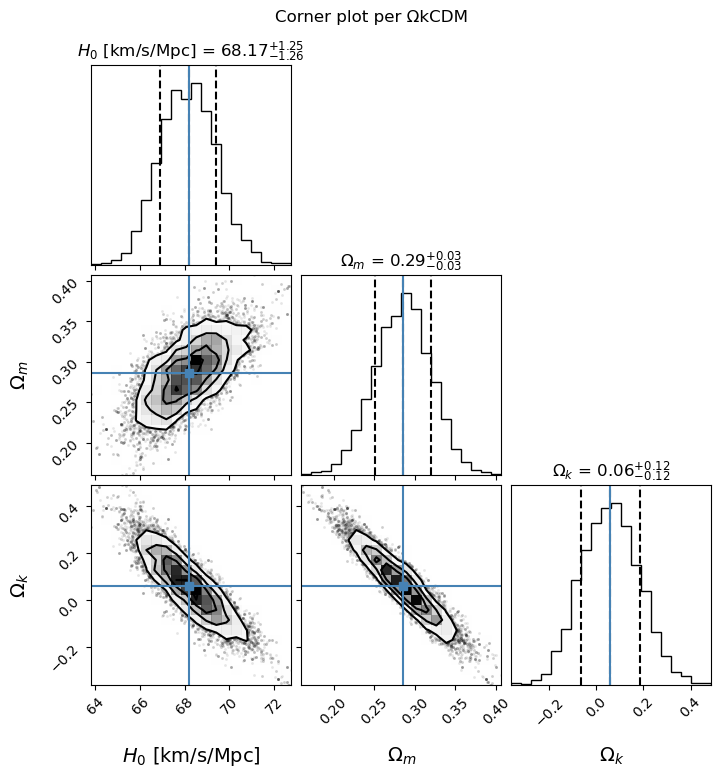

In [15]:
import corner
import matplotlib.pyplot as plt

labels_dict = {
    'ΛCDM':    [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$"],
    'wCDM':    [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$", r"$w$"],
    'ΩkCDM':   [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$", r"$\Omega_k$"],
    'w0waCDM': [r"$H_0\ \mathrm{[km/s/Mpc]}$", r"$\Omega_m$", r"$w_0$", r"$w_a$"],
}

for name, sampler in samplers.items():
    flat_chain = sampler.get_chain(discard=burn, flat=True)
    labels     = labels_dict[name]
    truths     = results[name]

    fig = corner.corner(
        flat_chain,
        labels=labels,
        show_titles=True,
        quantiles=[0.16, 0.5, 0.84],
        title_fmt=".2f",
        title_kwargs={"fontsize": 12},
        label_kwargs={"fontsize": 14},
        truths=truths
    )
    fig.suptitle(f"Corner plot per {name}", y=1.02)
    plt.show()


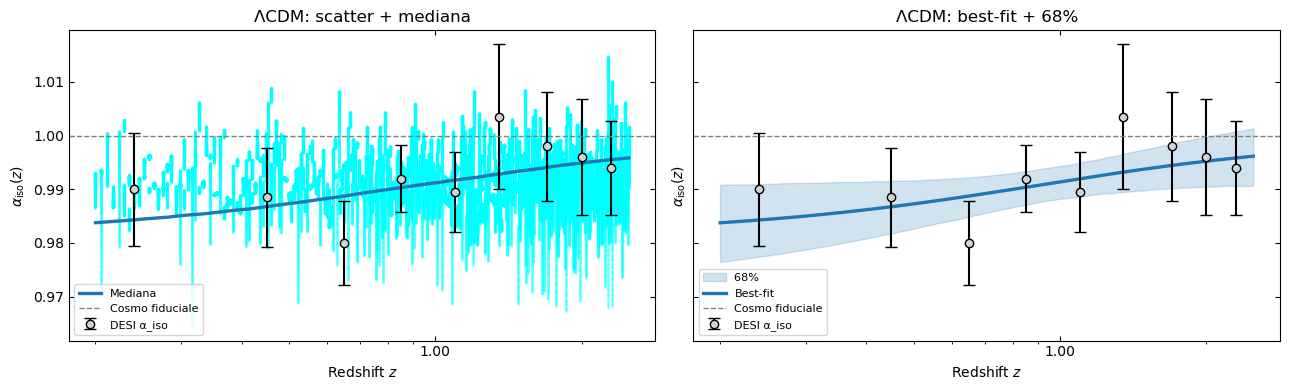

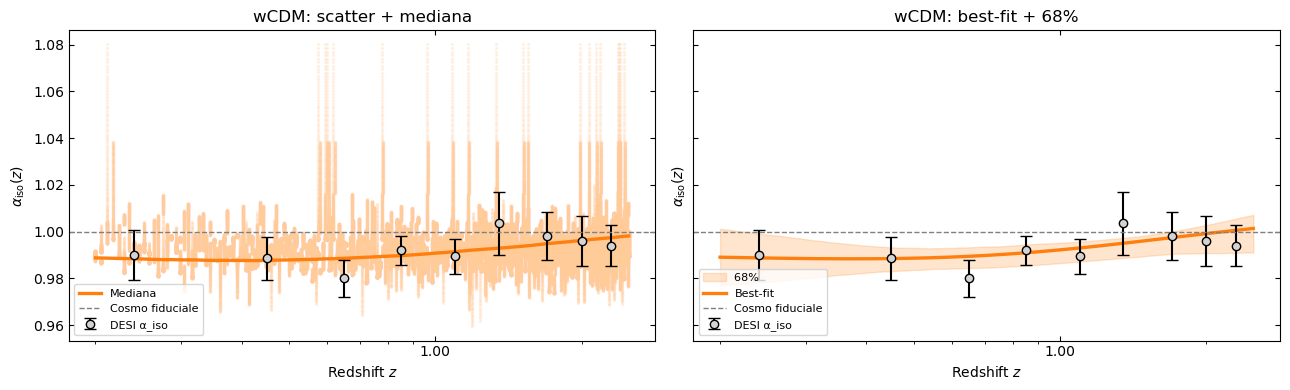

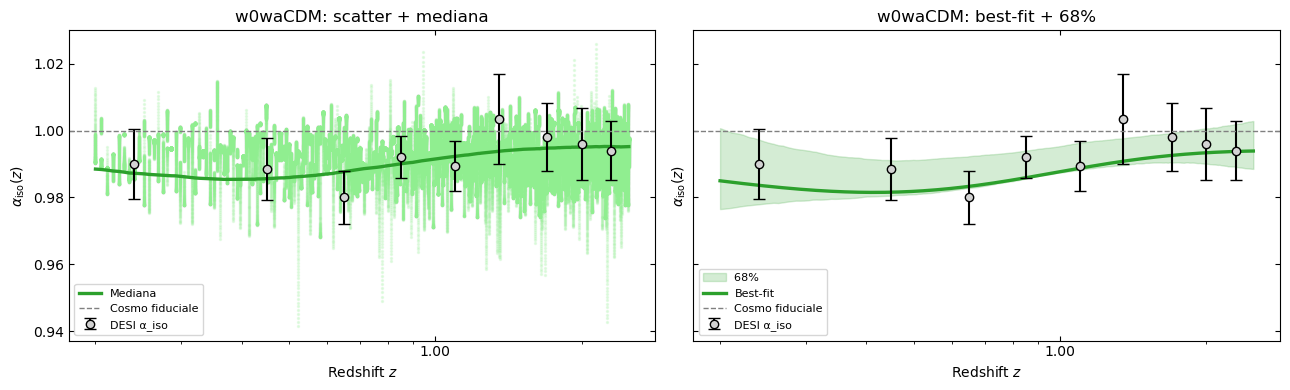

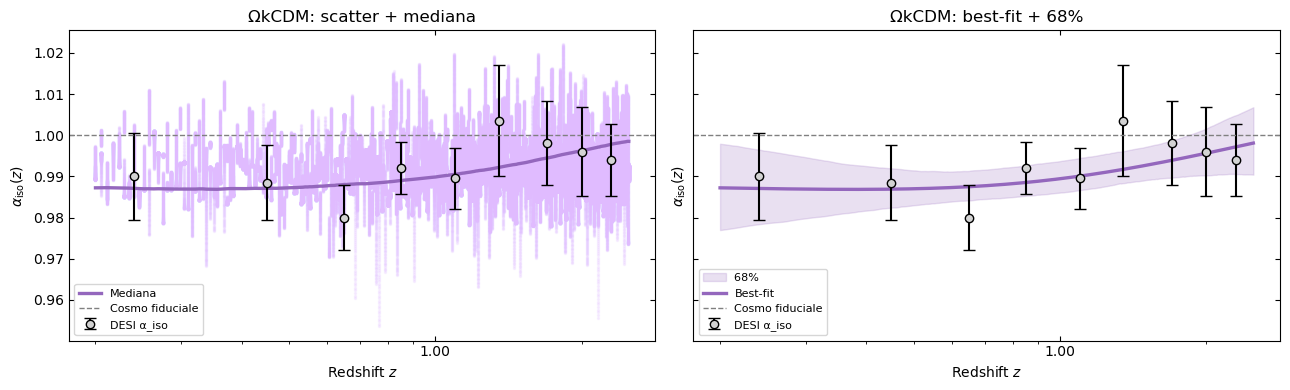

In [12]:
color_map = {'ΛCDM':'tab:blue','wCDM':'tab:orange','w0waCDM':'tab:green','ΩkCDM':'tab:purple'}
scatter_map = {'ΛCDM':'cyan','wCDM':'#ffcc99','w0waCDM':'lightgreen','ΩkCDM':'#e0bbff'}

N_scat  = 300
N_band  = 2000
z_dense = np.linspace(0.2, 2.5, 400)
Dv_fid_dense = dv_rd_modelNew(z_dense, fid_cosmo)

for name, sampler in samplers.items():
    tag = MODELS[name]
    col = color_map[name]

    flat_chain = sampler.get_chain(discard=burn, flat=True)
    if flat_chain.size == 0:
        continue

    # Banda 68%
    n_band   = min(N_band, flat_chain.shape[0])
    idx_band = rng.choice(flat_chain.shape[0], size=n_band, replace=False)
    alpha_mat = np.array([
        dv_rd_modelNew(z_dense, build_cosmoNew(theta, tag=tag)) / Dv_fid_dense
        for theta in flat_chain[idx_band]
    ])
    alpha_med  = np.median(alpha_mat, axis=0)
    alpha_low  = np.percentile(alpha_mat, 16, axis=0)
    alpha_high = np.percentile(alpha_mat, 84, axis=0)

    # Best-fit mediano
    best = np.median(flat_chain, axis=0)
    cosmo_best = build_cosmoNew(best, tag=tag)
    alpha_best = dv_rd_modelNew(z_dense, cosmo_best) / Dv_fid_dense

    # Scatter
    scat_idx = rng.choice(n_band, size=min(N_scat, n_band), replace=False)

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

    axL.scatter(
        np.repeat(z_dense, scat_idx.size),
        alpha_mat[scat_idx].ravel(),
        s=2, alpha=0.2, color=scatter_map[name]
    )
    axL.plot(z_dense, alpha_med, ls="-", lw=2.4, color=col, label="Mediana")
    axL.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                 fmt="o", ms=6, mfc="lightgray", mec="k",
                 ecolor="k", capsize=4, label="DESI α_iso")
    axL.axhline(1, xmin=0.0, xmax=1.0, linestyle='--', linewidth=1, color='grey', label="Cosmo fiduciale")
    axL.set_title(f"{name}: scatter + mediana")

    axR.fill_between(z_dense, alpha_low, alpha_high,
                     color=col, alpha=0.20, label="68% ")
    axR.plot(z_dense, alpha_best, lw=2.4, color=col,
             label=f"Best-fit")
    axR.errorbar(z_data, alpha_data, yerr=alpha_sigma,
                 fmt="o", ms=6, mfc="lightgray", mec="k",
                 ecolor="k", capsize=4, label="DESI α_iso")
    axR.axhline(1, xmin=0.0, xmax=1.0, linestyle='--', linewidth=1, color='grey', label="Cosmo fiduciale")
    axR.set_title(f"{name}: best-fit + 68%")

    for ax in (axL, axR):
        ax.set_xscale("log")
        #ax.set_xlim(0.2, 2.5); ax.set_ylim(0.9, 1.1)
        ax.set_xlabel("Redshift $z$")
        ax.set_ylabel(r"$\alpha_{\mathrm{iso}}(z)$")
        ax.xaxis.set_major_formatter(ScalarFormatter()); ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.tick_params(direction='in', top=True, right=True)
        ax.legend(fontsize=8, loc='lower left')

    fig.tight_layout()
    plt.show()


In [13]:
for name, theta_med in results.items():
    param_names = ['H0', 'Ωm']
    if name == 'wCDM':
        param_names.append('w0')
    if name == 'w0waCDM':
        param_names += ['w0', 'wa']
    if name == 'ΩkCDM':
        param_names.append('Ωk')
    params_str = ', '.join(f"{pn}={val:.3f}" for pn, val in zip(param_names, theta_med))
    print(f"{name} → {params_str}")


ΛCDM → H0=68.699, Ωm=0.301
wCDM → H0=67.924, Ωm=0.298, w0=-0.940
w0waCDM → H0=67.356, Ωm=0.320, w0=-0.815, wa=-0.648
ΩkCDM → H0=68.169, Ωm=0.286, Ωk=0.060
